# MEED on real cleaned EEG data

This notebook is intentionally narrow. `MEED-method.ipynb` already contains the method-development work, including the synthetic/null simulations. Here we only apply the fixed MEED representation to already cleaned EDF recordings.

The first target is not smoothing, thresholding, sequence metrics, or clinical interpretation. The first target is to verify that, for each raw object, we can extract: subject maps and their MEED representation; meta maps and their MEED representation; optional group maps and their MEED representation; samplewise correlations to both subject and meta maps; samplewise MEED coordinates directly from the data; samplewise angular distances from the data MEED to each template MEED.

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

import utils as u
import utils_realdata as ur

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_ROOT = Path("F:/Data/LEMON/vetted")
JSON_PATH = "metamaps_export_lemon.json"
OUTDIR = Path("results-realdata-lemon")
OUTDIR.mkdir(exist_ok=True)
FIF_OR_EDF = 'FIF'  # Change to 'FIF' if using .fif files
K = 4
N_TO_LOAD = None
RANDOM_STATE = 0

RUN_SUBJECT_FIT = True
RUN_GROUP_FIT = False
RUN_ALL_RECORDINGS = False

## 1. Files and channel conventions

The current exported format is simple: cleaned EDF files contain only actual EEG channels typed as `eeg`, and optional CSV sidecars can be used later for grouping. For now we ignore the CSV columns and use the alternating split `0::2` and `1::2` only to define two provisional groups.

The helper `standard_names_picker()` strips channel-name whitespace, maps legacy labels such as `T3/T4/T5/T6` to `T7/T8/P7/P8`, sets `standard_1020` when possible, and then keeps only EEG channels.

In [3]:
import glob
eeg_files = [Path(p) for p in glob.glob(str(DATA_ROOT / "**" / "*.fif" if FIF_OR_EDF == 'FIF' else "**" / "*.edf"), recursive=True)]
if N_TO_LOAD is not None:
    eeg_files = eeg_files[:N_TO_LOAD]

csv_files = [p for p in eeg_files if p.suffix.lower() == ".csv"]

print(f"Found {len(eeg_files)} EEG files in {DATA_ROOT.resolve() if DATA_ROOT.exists() else DATA_ROOT}")
print(f"CSV files: {len(csv_files)}")
print(eeg_files)

if eeg_files:
    if FIF_OR_EDF == 'EDF':
        r = mne.io.read_raw_edf(eeg_files[0], preload=False, verbose="ERROR")
    elif FIF_OR_EDF == 'FIF':
        r = mne.io.read_raw_fif(eeg_files[0], preload=False, verbose="ERROR")
    r = ur.standard_names_picker(r)
    print(*(f"\n{cht} :: {chn}" for cht, chn in zip(r.get_channel_types(), r.ch_names)))
else:
    print("No EEG files found. Set DATA_ROOT before running the real-data cells.")

Found 190 EEG files in F:\Data\LEMON\vetted
CSV files: 0
[WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010002_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010003_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010004_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010005_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010006_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010007_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010010_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010012_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010016_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010017_EC_64avgref_raw.fif'), WindowsPath('F:/Data/LEMON/vetted/fif_ec_64avgref/sub-010019_EC_64avgref_raw.fif'), WindowsPath('F:/Da

## 2. Load meta-microstates with the existing method utilities

We keep the original loading and visualization path. The validated utility returns the normalized channel-by-map matrix `B`, channel names, labels, and MNE `info`. This is the template channel order that every real EDF will be aligned to.

B is channels x maps: (63, 4) with labels ['A', 'B', 'C', 'D']


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,44.053181,6.940631,0.995914,0.991844,0.991828
1,meta,B,-48.681305,-0.450670,0.994916,0.989858,0.989832
2,meta,C,1.464695,-16.823206,0.998816,0.997634,0.997632
3,meta,D,-6.130269,35.291236,0.995719,0.991456,0.991438


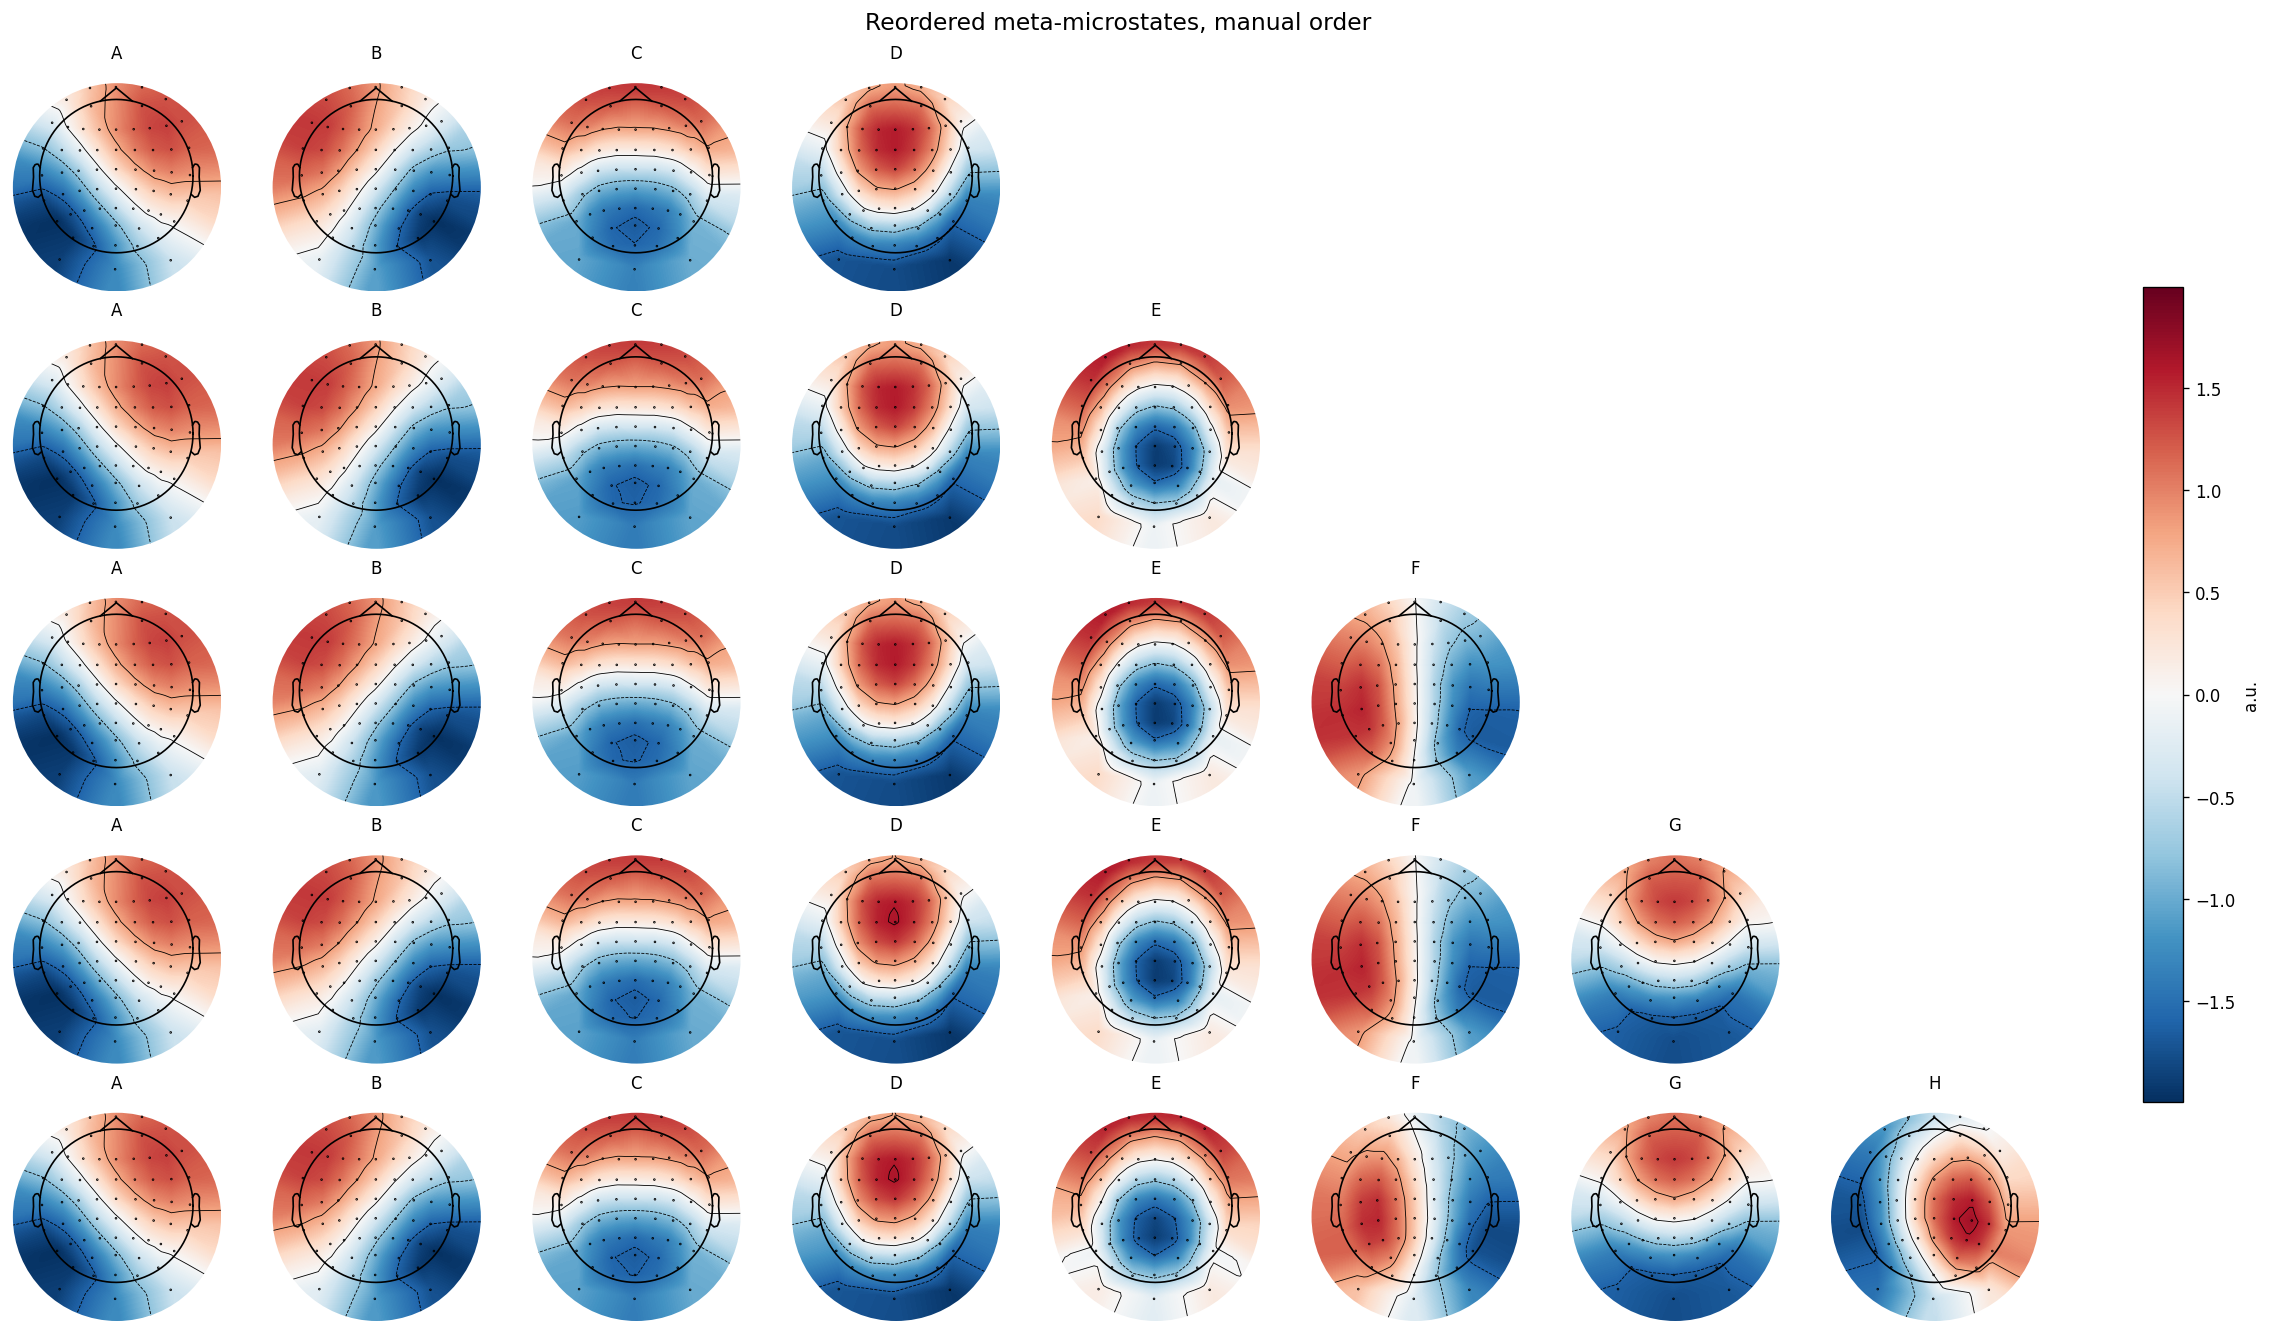

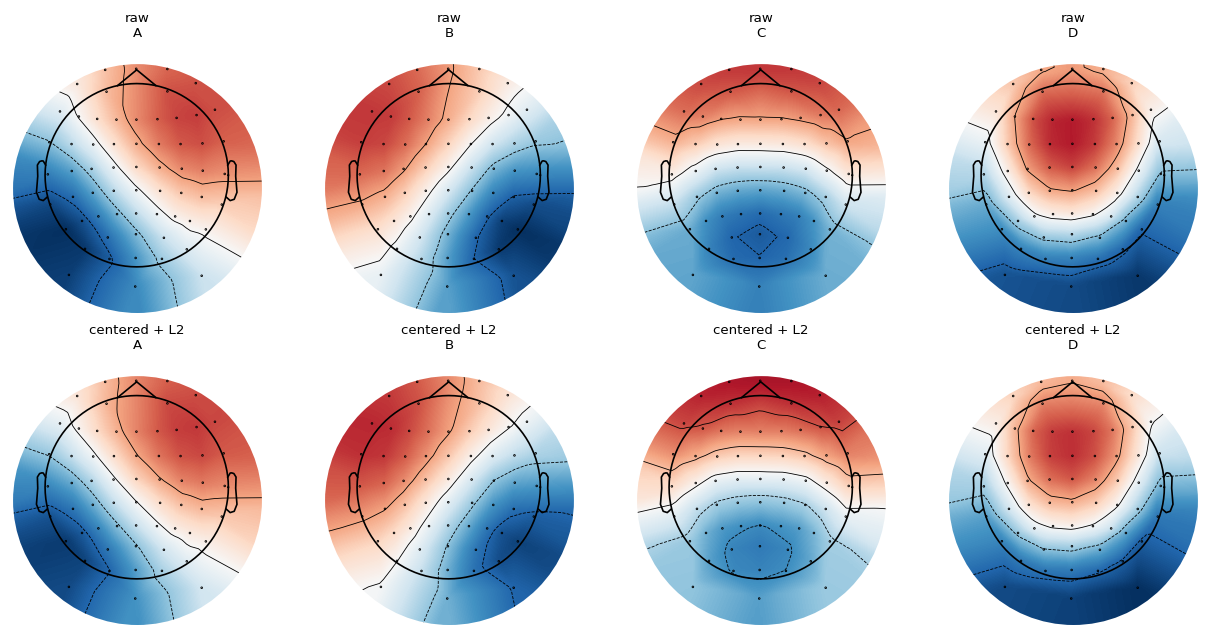

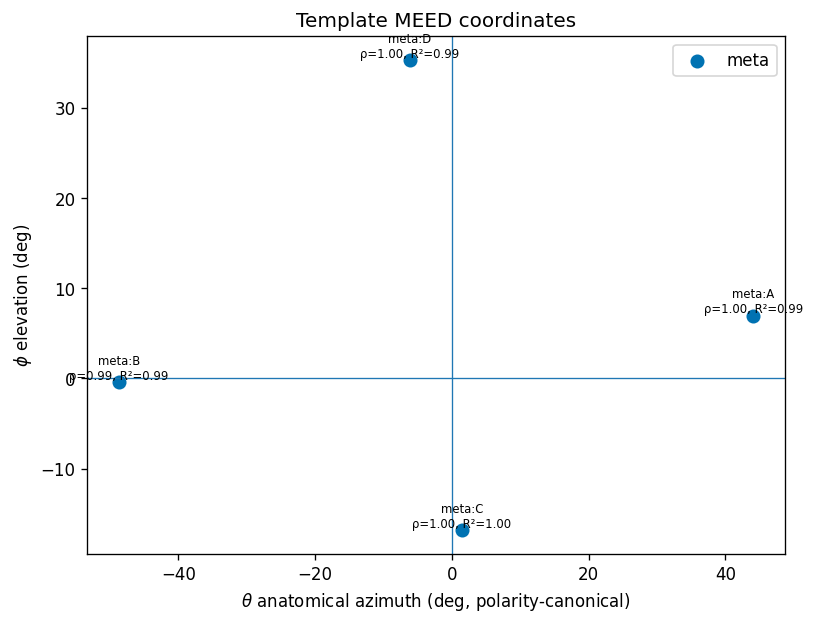

In [4]:
ds = u.load_microstates(JSON_PATH, K)
fig = u.plot_reordered_metamaps_all_k(ds, normalized=False)

print(f"B is channels x maps: {ds['B'].shape} with labels {ds['labels']}")
fig = u.plot_raw_and_normalized(ds["raw"], ds["B"], ds["labels"], ds["info"])

B, ch_names, labels, info = ds["B"], ds["ch_names"], ds["labels"], ds["info"]
meta_level = ur.build_template_level("meta", B, labels, info)

display(ur.template_level_summary(meta_level))
fig = ur.plot_template_meed_coordinates({"meta": meta_level})

In [5]:
for k in range(4,9):
    ds = u.load_microstates(JSON_PATH, k)
    #fig = u.plot_reordered_metamaps_all_k(ds, normalized=False)

    #print(f"B is channels x maps: {ds['B'].shape} with labels {ds['labels']}")
    #fig = u.plot_raw_and_normalized(ds["raw"], ds["B"], ds["labels"], ds["info"])

    B, ch_names, labels, info = ds["B"], ds["ch_names"], ds["labels"], ds["info"]
    meta_level = ur.build_template_level("meta", B, labels, info)

    display(ur.template_level_summary(meta_level))


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,44.053181,6.940631,0.995914,0.991844,0.991828
1,meta,B,-48.681305,-0.450670,0.994916,0.989858,0.989832
2,meta,C,1.464695,-16.823206,0.998816,0.997634,0.997632
3,meta,D,-6.130269,35.291236,0.995719,0.991456,0.991438


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,44.032251,6.887371,0.995918,0.991853,0.991836
1,meta,B,-48.317870,0.091207,0.994916,0.989858,0.989832
2,meta,C,1.503353,-14.772378,0.998765,0.997531,0.997529
3,meta,D,-5.975839,35.374437,0.995694,0.991407,0.991388
4,meta,E,-9.904214,-52.940434,0.997302,0.994611,0.994604


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,43.661351,6.951421,0.995914,0.991845,0.991828
1,meta,B,-46.318173,-0.104077,0.995399,0.990819,0.990797
2,meta,C,1.505179,-14.830849,0.998764,0.997530,0.997528
3,meta,D,-5.958164,35.331295,0.995706,0.991431,0.991412
4,meta,E,-9.904215,-52.940434,0.997302,0.994611,0.994604
5,meta,F,-88.057261,2.530864,0.983904,0.968067,0.967808


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,43.724697,6.928301,0.995914,0.991844,0.991828
1,meta,B,-46.440270,-0.211735,0.995392,0.990805,0.990784
2,meta,C,1.651851,-16.494992,0.998670,0.997343,0.997341
3,meta,D,-7.302397,38.268343,0.994979,0.989983,0.989958
4,meta,E,-9.931134,-52.666956,0.997334,0.994676,0.994669
5,meta,F,-88.057261,2.530864,0.983904,0.968067,0.967808
6,meta,G,-0.695347,16.794778,0.997744,0.995494,0.995489


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,43.724697,6.928301,0.995914,0.991844,0.991828
1,meta,B,-46.594043,-0.232178,0.995363,0.990748,0.990726
2,meta,C,1.651533,-16.490654,0.998671,0.997343,0.997341
3,meta,D,-7.302397,38.268343,0.994979,0.989983,0.989958
4,meta,E,0.803234,-49.787333,0.997386,0.994778,0.994772
5,meta,F,-89.328566,14.617847,0.986309,0.972805,0.972618
6,meta,G,-0.695348,16.794778,0.997744,0.995494,0.995489
7,meta,H,-85.587783,-32.970828,0.984563,0.969364,0.969125


## 3. One raw object: align channels, fit subject maps, compute MEED

This section is deliberately procedural: each computational object is followed by either a dataframe display or a plot. We first align one raw object to the meta-template channel order, then fit subject-specific maps with pycrostates, then build the subject MEED level, then compare subject maps with meta maps. If group maps have already been created in the session, the same plotting functions also accept any number of group levels.

The important diagnostic here is not only where a map lands in $(\theta,\phi)$, but also its $\rho$ and $R^2=\rho^2$. If a subject map collapses toward a non-lateralized or low-elevation region and has low $R^2$, that is not "close to C" in a meaningful sense: it is a weak fixed-MEED description of that template.

<RawEDF | sub-1_ses-ADM_eeg.edf, 19 x 38144 (298.0 s), ~5.6 MiB, data loaded>
{'sub': '1', 'ses': 'ADM', 'recording': 'sub-1_ses-ADM_eeg'}

eeg :: Fp1 
eeg :: Fp2 
eeg :: F7 
eeg :: F3 
eeg :: Fz 
eeg :: F4 
eeg :: F8 
eeg :: C3 
eeg :: Cz 
eeg :: C4 
eeg :: T8 
eeg :: P7 
eeg :: P3 
eeg :: Pz 
eeg :: P4 
eeg :: P8 
eeg :: O1 
eeg :: O2 
eeg :: T7
Loading subject level from disk...


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,subject,A,41.326173,12.385859,0.980014,0.960428,0.960029
1,subject,B,-57.783161,-8.185235,0.977262,0.955041,0.954524
2,subject,C,-2.285557,-17.178712,0.944091,0.891307,0.888182
3,subject,D,-6.067354,-17.010599,0.153454,0.023548,-0.693093


,level,label,theta_deg,phi_deg,rho,MEED_projection_R2,R2
0,meta,A,45.012159,3.580770,0.978294,0.957058,0.956587
1,meta,B,-47.211409,-2.630520,0.974976,0.950579,0.949952
2,meta,C,0.995031,-12.947074,0.983515,0.967303,0.967031
3,meta,D,-7.199340,32.609720,0.985230,0.970679,0.970461
4,subject,A,41.326173,12.385859,0.980014,0.960428,0.960029
5,subject,B,-57.783161,-8.185235,0.977262,0.955041,0.954524
6,subject,C,-2.285557,-17.178712,0.944091,0.891307,0.888182
7,subject,D,-6.067354,-17.010599,0.153454,0.023548,-0.693093


,a_index,a_label,b_index,b_label,abs_corr,signed_corr,MEED_angle_deg
0,0,A,0,A,0.942263,0.942263,9.530276
1,1,B,1,B,0.954752,0.954752,11.896728
2,2,C,2,C,0.910938,0.910938,5.285492
3,3,D,3,D,0.124850,0.124850,49.632142


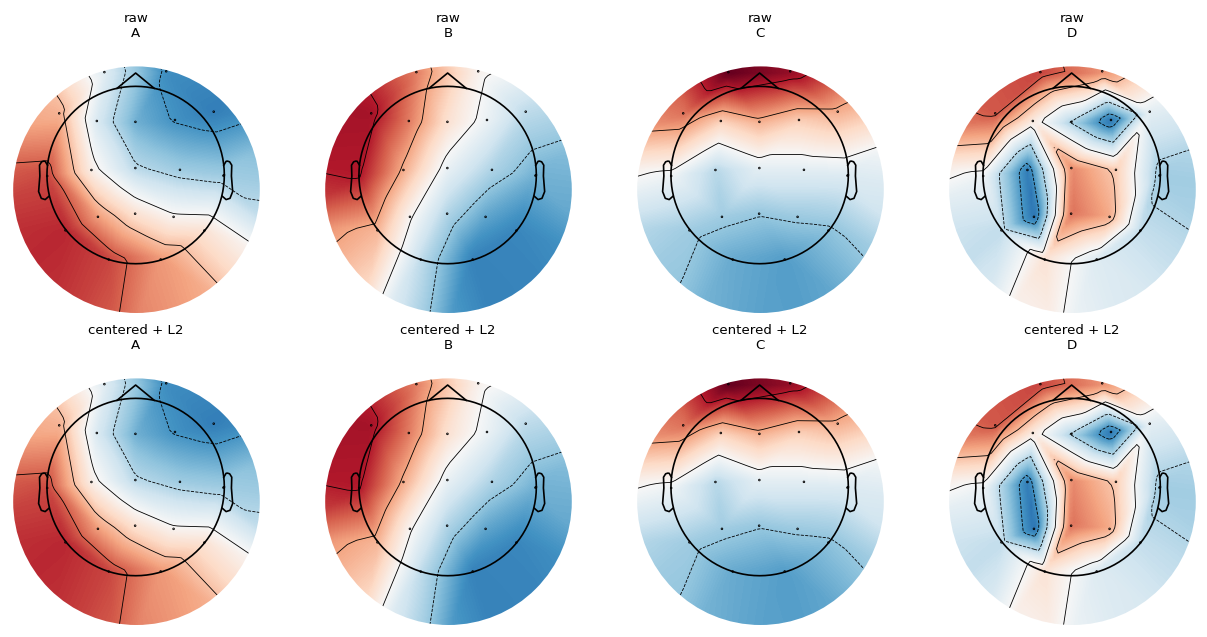

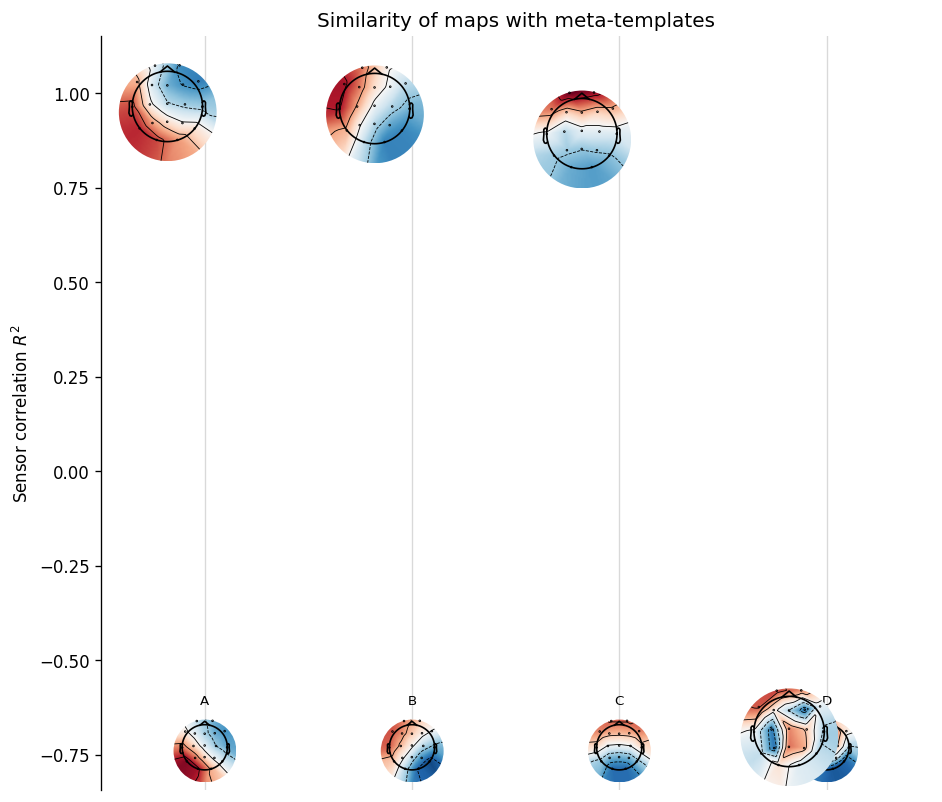

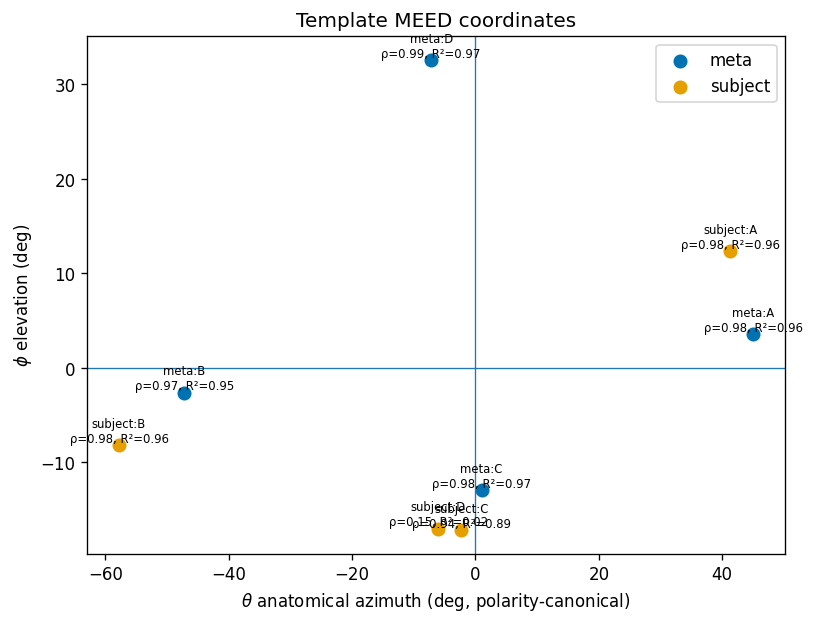

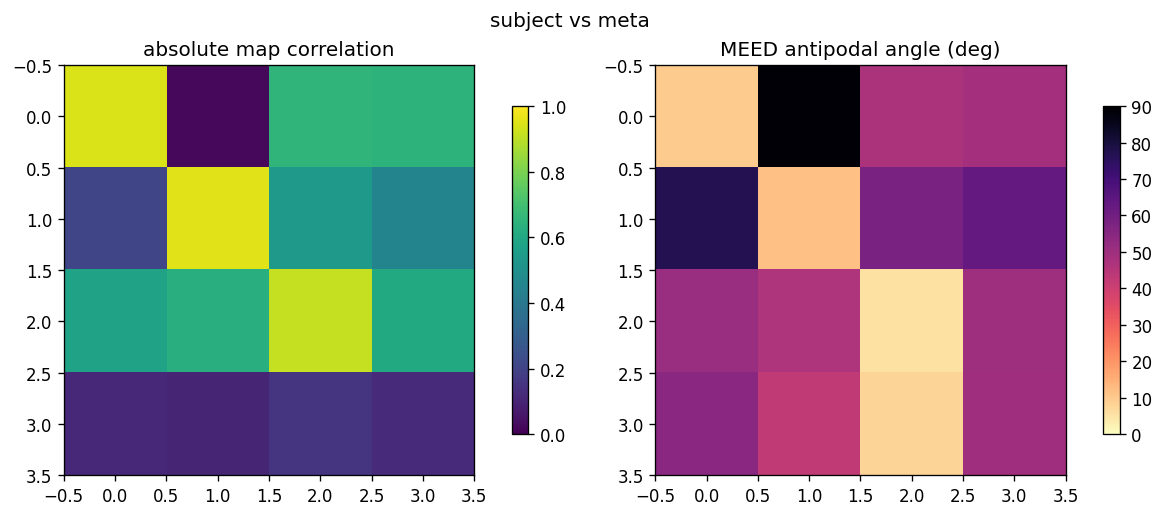

In [ ]:

# Tool 1: load and align one raw object.
raw = ur.load_edf_as_eeg(edf_files[0], preload=True)
raw = ur.align_raw_to_template_channels(raw, ch_names, strict=True)
recording_info = ur.parse_recording_info(edf_files[0])

print(raw)
print(recording_info)
print(*(f"\n{cht} :: {chn}" for cht, chn in zip(raw.get_channel_types(), raw.ch_names)))

# Tool 2: fit subject maps and polarity/reorder-align them to the meta maps.
if try_skip_micro := True and (OUTDIR / "subject_level.pkl").exists():
    print("Loading subject level from disk...")
    subject_level = pd.read_pickle(OUTDIR / "subject_level.pkl")
else:
    subject_level = ur.fit_subject_template_level(
        raw,
        n_clusters=K,
        random_state=RANDOM_STATE,
        reference_level=meta_level,
        name="subject",
        )
    pd.to_pickle(subject_level, OUTDIR / "subject_level.pkl")
    

# Output 2a: subject maps.
display(ur.template_level_summary(subject_level))
fig = u.plot_raw_and_normalized(subject_level.B, subject_level.B, subject_level.labels, subject_level.info)

# Tool 3: collect all available template levels.
levels_for_display = {"meta": meta_level, "subject": subject_level}

# Output 3a: normalized maps across levels: meta, subject, optional groups.
fig = ur.plot_template_maps_grid(levels_for_display, 
                                    r2_kind = "sensor",
                                    level_topomap_scale = 2,
                                    title="Similarity of maps with meta-templates")
fig.savefig(OUTDIR / "template_maps_grid.svg", bbox_inches="tight")

# Output 3b: MEED coordinate table across levels.
display(pd.concat([ur.template_level_summary(level) for level in levels_for_display.values()], ignore_index=True))

# Output 3c: MEED coordinates annotated with label, rho, and R2.
fig = ur.plot_template_meed_coordinates(levels_for_display, annotate="rho_R2")

# Tool 4: subject vs meta comparison.
cmp_subject_meta = ur.compare_template_levels(subject_level, meta_level)

# Output 4a: matched map table.
display(cmp_subject_meta["matched"])

# Output 4b: sensor-correlation and MEED-angle comparison matrices.
fig = ur.plot_template_comparison_heatmaps(cmp_subject_meta, title="subject vs meta")


## 4. Per-sample real-data MEED table

For each EEG sample $x_t$, we compute the centered and L2-normalized topography $\tilde x_t$, then project it directly into the fixed MEED geometry:

$$
q_t=S_{\mathrm{orth}}^\top\tilde x_t
$$

$$
\rho_t=\|q_t\|
$$

$$
u_t=q_t/\rho_t
$$

$$
D_t=(\theta_t,\phi_t)
$$

The sample table now keeps the columns needed for this first real-data layer: `sub`, `ses`, `time`, `GFP`, `TD`, all compact correlations to meta maps such as `C_Ameta`, all compact correlations to subject maps such as `C_Asub`, the data MEED coordinates `theta`, `phi`, `rho`, and component/composite distances to each template such as `theta_Ameta`, `phi_Ameta`, `angle_Ameta`, `theta_Asub`, `phi_Asub`, `angle_Asub`.

The template-free quantity is $\rho_t^2$: it tells us whether the data topography itself survives the fixed MEED scaffold. The template-specific quantities are the correlations and the angular distances to meta or subject maps.

Loading sample_df from disk...


,sub,ses,time,GFP,TD,C_Ameta,C_Bmeta,C_Cmeta,C_Dmeta,C_Asub,...,theta_Csub,theta_Dsub,phi_Asub,phi_Bsub,phi_Csub,phi_Dsub,angle_Asub,angle_Bsub,angle_Csub,angle_Dsub
3841,1,ADM,30.007812,0.000004,0.840400,0.808961,0.275940,0.753204,0.687483,0.895411,...,29.095915,32.877712,7.679887,12.891208,21.884685,21.716572,16.269054,85.338661,36.120507,39.069656
3842,1,ADM,30.015625,0.000004,0.578985,0.785882,0.100075,0.397738,0.605318,0.919615,...,52.173808,55.955605,15.572851,36.143946,45.137423,44.969310,17.508010,70.600883,67.724948,70.384680
3843,1,ADM,30.023438,0.000006,0.481823,0.613510,0.463340,0.036923,0.235005,0.748109,...,83.443766,87.225563,12.445015,33.016109,42.009587,41.841474,39.575489,42.511187,88.565677,85.362814
3844,1,ADM,30.031250,0.000006,0.383137,0.362185,0.678338,0.289910,0.060522,0.484417,...,73.679260,69.897464,35.435098,14.864004,5.870527,6.038640,60.259941,22.917978,68.735007,65.356809
3845,1,ADM,30.039062,0.000005,0.349134,0.120680,0.809618,0.539365,0.321932,0.197250,...,54.555737,50.773940,29.783951,9.212857,0.219380,0.387493,78.664844,9.258416,51.902182,48.354141


gfp_mean                                          0.000004
gfp_median                                        0.000004
backward_topographic_dissimilarity_mean           0.640223
backward_topographic_dissimilarity_median         0.592850
MEED_projection_R2_mean                           0.640660
MEED_projection_R2_median                         0.685314
MEED_backward_angular_velocity_deg_s_mean      5430.768568
MEED_backward_angular_velocity_deg_s_median    3463.234360
meta_corr_best_R2_mean                            0.492938
meta_corr_best_R2_median                          0.507027
meta_angle_min_deg_mean                          26.859474
meta_angle_min_deg_median                        24.093953
subject_corr_best_R2_mean                         0.495224
subject_corr_best_R2_median                       0.508953
subject_angle_min_deg_mean                       29.001555
subject_angle_min_deg_median                     26.555380
dtype: float64

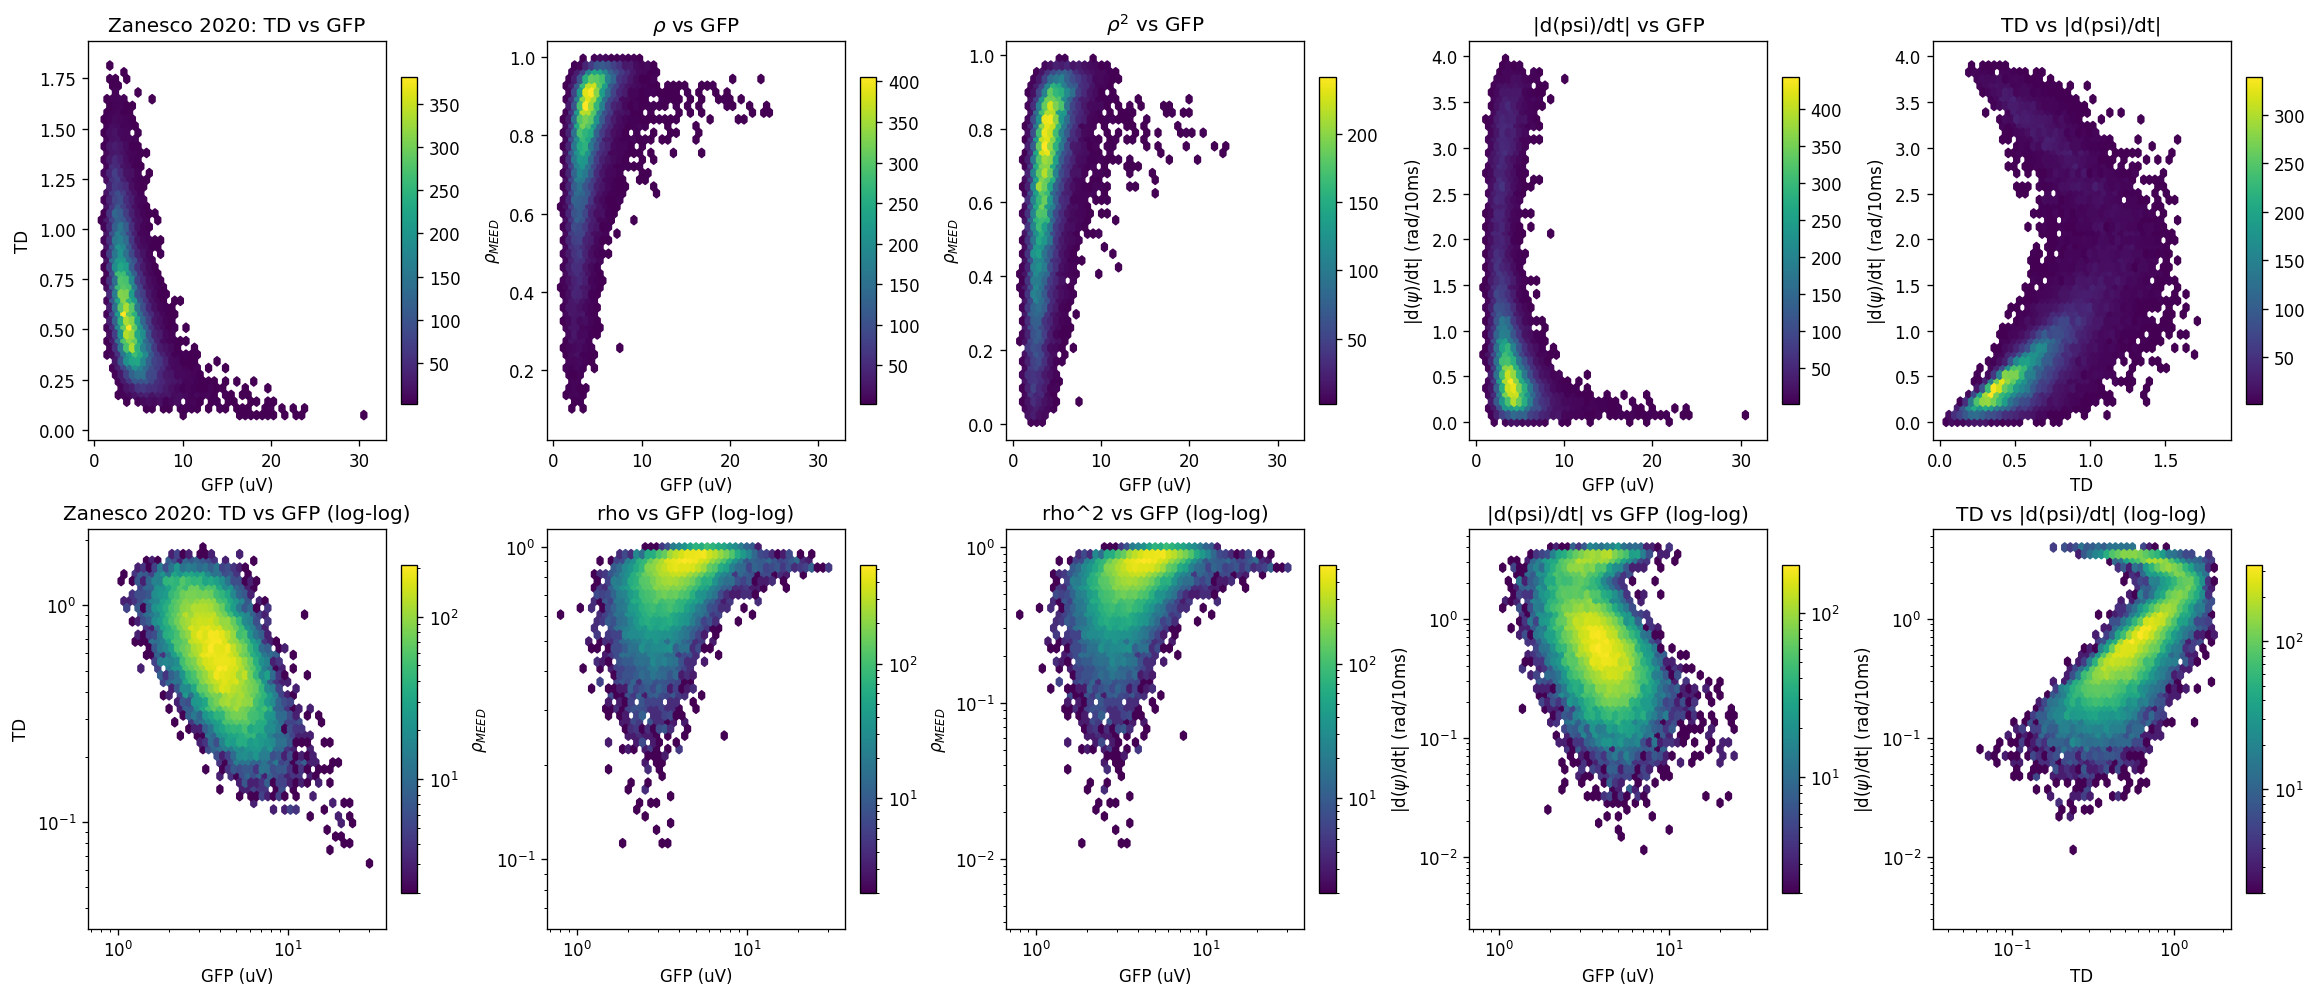

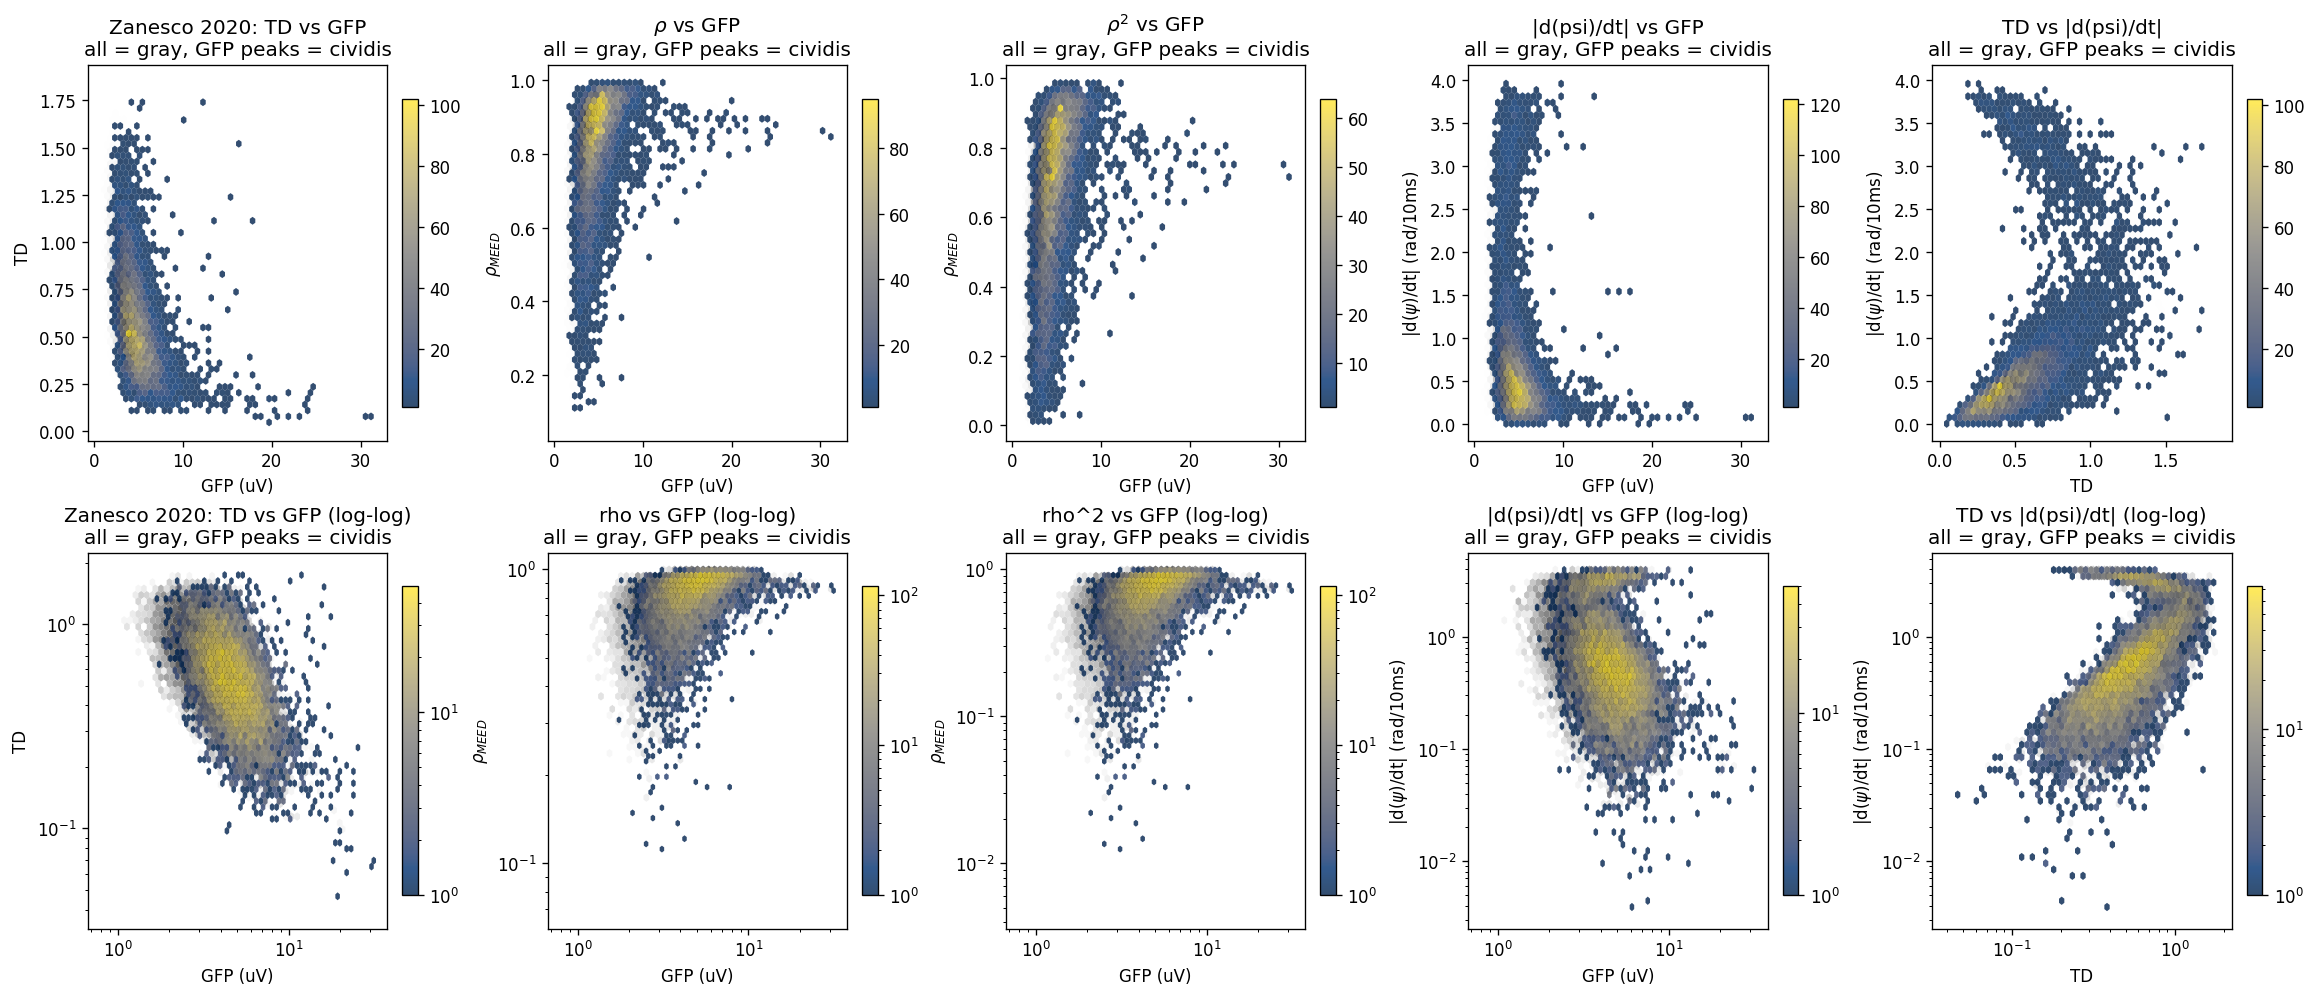

In [5]:
if edf_files and RUN_SUBJECT_FIT:
    template_levels = {
        "meta": meta_level,
        "subject": subject_level,
    }
    
    if try_skip_sample:=True and (OUTDIR / "sample_df.csv").exists():
        print("Loading sample_df from disk...")
        sample_df = pd.read_csv(OUTDIR / "sample_df.csv")
        sample_matrices = None
    else:
        sample_df, sample_matrices = ur.characterize_raw_with_template_levels(
            raw,
            template_levels,
            data_geometry_level="meta",
            recording_info=recording_info,
        )
        sample_df.to_csv(OUTDIR / "sample_df.csv", index=False)

    requested_cols = [
        "sub", "ses", "time", "GFP", "TD",
        *[f"C_{lab}meta" for lab in labels],
        *[f"C_{lab}sub" for lab in labels],
        "theta", "phi", "rho",
        *[f"theta_{lab}meta" for lab in labels],
        *[f"phi_{lab}meta" for lab in labels],
        *[f"angle_{lab}meta" for lab in labels],
        *[f"theta_{lab}sub" for lab in labels],
        *[f"phi_{lab}sub" for lab in labels],
        *[f"angle_{lab}sub" for lab in labels],
    ]
    requested_cols = [c for c in requested_cols if c in sample_df.columns]
    
    sample_df = sample_df.query("30<time<270")

    display(sample_df[requested_cols].head())
    display(ur.summarize_sample_features(sample_df))

    dur_s = min(2, float(sample_df["time"].max()))
    # plt.switch_backend("QtAgg")
    # fig = ur.plot_subject_timeseries_detail(sample_df, labels=labels, start_s=30, stop_s=30+dur_s)
    # plt.show(block=True)
    # %matplotlib inline

    fig = ur.plot_subject_feature_hexbins(sample_df)
    # fig = ur.plot_subject_uncertainty(sample_df,
    #                                   meta_level=meta_level,
    #                                   subject_level=subject_level,
    #                                   labels=labels,
    #                                   )
    fig = ur.plot_subject_feature_hexbins_peaks(sample_df)
    
    state_out = OUTDIR / "state-space"

    # ang = ur.run_angular_state_space_analysis(
    #     sample_df,
    #     outdir=state_out / "angular",
    # )

    # dip = ur.run_dipole_state_space_analysis(
    #     sample_df,
    #     outdir=state_out / "dipole",
    #     angular_result=ang,
    # )

else:
    print("Skipped samplewise characterization.")

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

# ang = ur.run_angular_state_space_analysis(
#     sample_df,
#     outdir=state_out / "angular",
# )

ang = ur.run_angular_state_space_analysis(
        sample_df,
        outdir=state_out / "angular",
    )


import matplotlib.pyplot as plt
plt.switch_backend("TkAgg")
plt.ion()
dip = ur.run_dipole_state_space_analysis(
    sample_df,
    outdir=state_out / "dipole",
    angular_result=ang,
)
plt.show(block=True)
%matplotlib inline

AttributeError: type object 'FigureManagerBase' has no attribute '_owns_mainloop'

## 5. Optional group-level maps

The provisional grouping rule is deliberately crude: `edf_files[0::2]` and `edf_files[1::2]`. CSV sidecars are available for later grouping, but not used here.

The group fit concatenates aligned EDFs in memory and fits pycrostates on the resulting group-level raw object. This is optional because it is heavier than the one-subject check.

In [ ]:
group_files = {
    "group_0": edf_files[0::2],
    "group_1": edf_files[1::2],
}
for g, files in group_files.items():
    print(g, len(files), files)

group_levels = {}

if RUN_GROUP_FIT and edf_files:
    for g, files in group_files.items():
        if len(files) == 0:
            continue
        group_levels[g] = ur.fit_group_template_level(
            files,
            ch_names,
            n_clusters=K,
            random_state=RANDOM_STATE,
            reference_level=meta_level,
            name=g,
        )

    for g, level in group_levels.items():
        display(ur.template_level_summary(level))
        cmp_group_meta = ur.compare_template_levels(level, meta_level)
        display(cmp_group_meta["matched"])
        fig = ur.plot_template_comparison_heatmaps(cmp_group_meta, title=f"{g} vs meta")

    fig = ur.plot_template_meed_coordinates({"meta": meta_level, **group_levels})
else:
    print("Skipped group-level fit. Set RUN_GROUP_FIT=True when ready.")

group_0 3 [WindowsPath('data-std/sub-1_ses-ADM_eeg.edf'), WindowsPath('data-std/sub-3_ses-ADM_eeg.edf'), WindowsPath('data-std/sub-6_ses-ADM_eeg.edf')]
group_1 2 [WindowsPath('data-std/sub-2_ses-ADM_eeg.edf'), WindowsPath('data-std/sub-4_ses-ADM_eeg.edf')]
Skipped group-level fit. Set RUN_GROUP_FIT=True when ready.


## 6. One-loop extraction across recordings

This loop still loads only one EDF at a time. For each recording it can fit subject maps, compute the subject/meta comparison, compute the per-sample MEED table, and write compact summaries.

The heavy per-sample tables can be exported one-by-one if needed. For now the loop is disabled by default because subject-level pycrostates fitting may take time.

In [ ]:
if RUN_ALL_RECORDINGS and edf_files:
    out_dir = Path("results-realdata")
    out_dir.mkdir(exist_ok=True)

    recording_summaries = []
    template_summaries = []

    for i, edf_path in enumerate(edf_files):
        print(f"[{i+1}/{len(edf_files)}] {edf_path}")
        raw_i = ur.load_edf_as_eeg(edf_path, preload=True)
        raw_i = ur.align_raw_to_template_channels(raw_i, ch_names, strict=True)

        subj_i = ur.fit_subject_template_level(
            raw_i,
            n_clusters=K,
            random_state=RANDOM_STATE + i,
            reference_level=meta_level,
            name="subject",
        )

        sample_i, _ = ur.characterize_raw_with_template_levels(
            raw_i,
            {"meta": meta_level, "subject": subj_i},
            data_geometry_level="meta",
        )

        rec_id = edf_path.stem
        sample_i.insert(0, "recording", rec_id)
        sample_i.to_csv(out_dir / f"{rec_id}__MEED_samples.csv", index=False)

        s = ur.summarize_sample_features(sample_i)
        s["recording"] = rec_id
        recording_summaries.append(s)

        ts = ur.template_level_summary(subj_i)
        ts.insert(0, "recording", rec_id)
        template_summaries.append(ts)

    recording_summary_df = pd.DataFrame(recording_summaries)
    template_summary_df = pd.concat(template_summaries, ignore_index=True)

    recording_summary_df.to_csv(out_dir / "recording_summary.csv", index=False)
    template_summary_df.to_csv(out_dir / "subject_template_summary.csv", index=False)

    display(recording_summary_df)
    display(template_summary_df)
else:
    print("Skipped all-recording loop. Set RUN_ALL_RECORDINGS=True when the single-recording check is clean.")

Skipped all-recording loop. Set RUN_ALL_RECORDINGS=True when the single-recording check is clean.


## 7. What this notebook does not do yet

This notebook stops here by design. It does not yet implement Pascual-Marqui smoothing, MEED cleaning, threshold grids, A/B/C/D comparisons, or sequence-metric convergence. Those later analyses only make sense after this first layer is verified: real EDFs load cleanly, subject maps can be fitted, meta/subject/group templates can be represented by MEED, and every time point has raw correlations, MEED coordinates, dipolarity, and angular distances.